In [1]:
%load_ext autoreload
%autoreload 2

import lovely_tensors as lt
import numpy as np
import torch
import torch.nn.functional as F

from uqct.ct import sample_observations, Experiment
from uqct.datasets.utils import get_dataset, DatasetName
from uqct.metrics import b_PSNR
from uqct.models.diffusion import Diffusion, get_guidance_loss_fn

lt.monkey_patch()

def lr2psnr(dataset: DatasetName, sparse: bool, cond: bool, total_intensity: float, lr: float) -> torch.Tensor:
    """Returns the PSNR of generated Diffusion samples."""

    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if torch.cuda.is_available():
        torch.set_float32_matmul_precision("high")
        torch.backends.cudnn.benchmark = True
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

    _, test_set = get_dataset(dataset, True)


    n_gt = min(10 if sparse else 3, len(test_set))

    gt = torch.stack([test_set[i] for i in range(n_gt)], dim=0).to(device)

    n_angles = 200

    angles = torch.from_numpy(np.linspace(0, 180, n_angles, endpoint=False)).to(device)
    n_detectors_hr = gt.shape[-1]
    intensities = torch.tensor(total_intensity, device=device)
    if sparse:
        intensities = intensities.view(1, 1, 1, 1).expand(n_gt, -1, n_angles, -1) / (
            n_angles * n_detectors_hr
        )
        schedule = torch.tensor([1, 50, 100, 150, 200])
    else:
        n_rounds = 1
        intensities = intensities.view(1, 1, 1, 1).expand(
            n_gt, n_rounds, n_angles, -1
        ) / (n_angles * n_detectors_hr * n_rounds)
        schedule = None
    counts = sample_observations(gt, intensities, angles)
    intensities_lr = intensities * 2
    experiment = Experiment(counts, intensities_lr, angles, sparse)
    diffusion = Diffusion(
        dataset,
        num_steps=100,
        sgd_steps=10,
        lr=lr,
        batch_size=16,
        cond=cond,
        verbose=False,
    )

    guidance_loss_fn = get_guidance_loss_fn(experiment, schedule)
    sample = diffusion.sample(experiment, 1 if experiment.sparse else 3, schedule, guidance_loss_fn)
    gt_lr = F.interpolate(gt, (128, 128), mode="area")
    gt_lr = gt_lr.unsqueeze(1).unsqueeze(1).expand(-1, -1, sample.shape[2], -1, -1, -1)
    return b_PSNR(gt_lr, sample)

In [2]:
from collections import defaultdict
from pathlib import Path
import pickle
from tqdm.auto import tqdm
from itertools import product

sparse = True
results_cache_path = Path.home() / f".cache/eval_{'sparse' if sparse else 'dense'}_results.pkl"
results = defaultdict(lambda: defaultdict(dict))  # results[dataset][lr][total_intensity] -> list[psnr]
lrs = [0.0] + (np.full((10,), 10) ** np.linspace(-3, 0, 10)).tolist()
datasets = ["composite", "lamino", "lung"]
total_intensities = [1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10]
params = list(product(datasets, lrs, total_intensities))

print(f"Learning rates: {lrs}")
print(f"Total intensities: {total_intensities}")
print(f"Number of parameter combinations: {len(params)}")
print("Cache path:", results_cache_path.absolute())

if results_cache_path.exists():
    results = pickle.load(results_cache_path.open("rb"))
else:
    pbar = tqdm(total=len(params))
    for dataset, lr, total_intensity in params:
        psnrs = lr2psnr(dataset, True, True, total_intensity, lr).tolist()
        results[dataset][lr][total_intensity] = psnrs
        pbar.update(1)
    results = dict(results)
    pickle.dump(results, results_cache_path.open('wb'))

Learning rates: [0.0, 0.001, 0.0021544346900318843, 0.004641588833612777, 0.01, 0.021544346900318832, 0.046415888336127774, 0.1, 0.21544346900318823, 0.46415888336127775, 1.0]
Total intensities: [1000.0, 10000.0, 100000.0, 1000000.0, 10000000.0, 100000000.0, 1000000000.0, 10000000000.0]
Number of parameter combinations: 264
Cache path: /home/mgaetzner/.cache/eval_sparse_results.pkl


  0%|          | 0/264 [00:00<?, ?it/s]

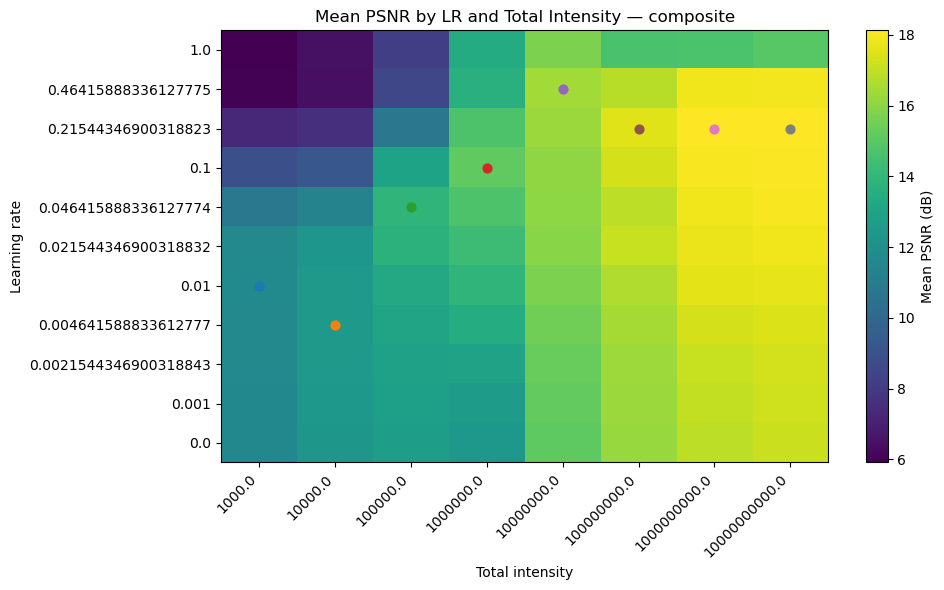

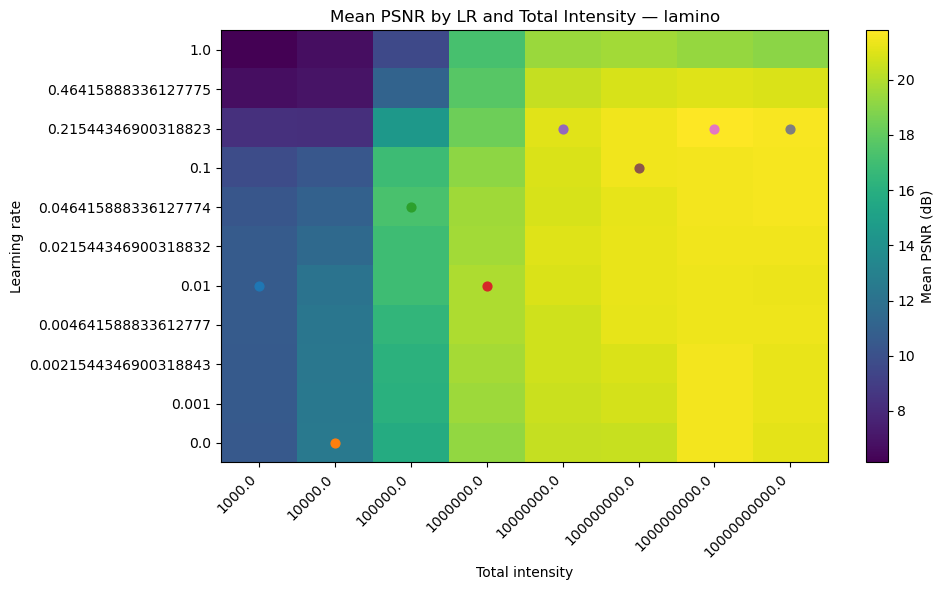

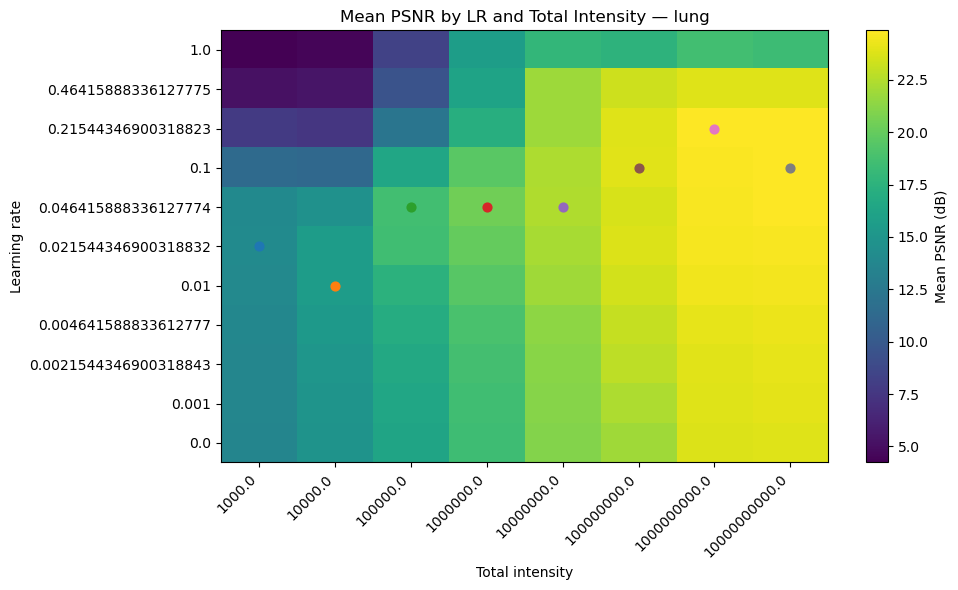

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def make_heatmap_for_dataset(dataset):
    # rows: lr, cols: total_intensity, values: mean PSNR
    data = []
    for lr in lrs:
        row = []
        for ti in total_intensities:
            ps = results[dataset][lr][ti]
            row.append(float(np.mean(ps)) if len(ps) else np.nan)
        data.append(row)

    df = pd.DataFrame(data, index=lrs,
                      columns=total_intensities)

    fig = plt.figure(figsize=(10, 6))
    plt.title(f"Mean PSNR by LR and Total Intensity — {dataset}")
    im = plt.imshow(df.values, aspect="auto", origin='lower')
    plt.colorbar(im, label="Mean PSNR (dB)")
    plt.xticks(range(len(df.columns)), df.columns, rotation=45, ha="right")
    plt.yticks(range(len(df.index)), df.index)
    plt.xlabel("Total intensity")
    plt.ylabel("Learning rate")

    # Mark the best LR per total_intensity (column-wise max)
    vals = df.values
    for j in range(vals.shape[1]):
        col = vals[:, j]
        if np.all(np.isnan(col)):
            continue
        i_star = int(np.nanargmax(col))
        plt.scatter(j, i_star, marker="o", s=40)  # no explicit color per your VS Code rules

    plt.tight_layout()
    plt.show()
    return df

dfs = {}
for ds in datasets:
    dfs[ds] = make_heatmap_for_dataset(ds)

In [7]:
best_tables = {}
for ds, df in dfs.items():
    best_lr_idx = df.idxmax(axis=0)   # index (lr as string) of max mean PSNR per column
    best_psnr = df.max(axis=0)
    best = pd.DataFrame({"best_lr": best_lr_idx, "best_mean_psnr": best_psnr})
    print(f"\nBest LR per total_intensity — {ds}")
    display(best)
    best_tables[ds] = best


Best LR per total_intensity — composite


,best_lr,best_mean_psnr
1.000000e+03,0.010000,11.709901
1.000000e+04,0.004642,12.476555
1.000000e+05,0.046416,13.920953
1.000000e+06,0.100000,15.123518
1.000000e+07,0.464159,16.440793
1.000000e+08,0.215443,17.523840
1.000000e+09,0.215443,18.100595
1.000000e+10,0.215443,18.126085



Best LR per total_intensity — lamino


,best_lr,best_mean_psnr
1.000000e+03,0.010000,10.645250
1.000000e+04,0.000000,12.434538
1.000000e+05,0.046416,17.295837
1.000000e+06,0.010000,19.860868
1.000000e+07,0.215443,21.102861
1.000000e+08,0.100000,21.476025
1.000000e+09,0.215443,21.791768
1.000000e+10,0.215443,21.656297



Best LR per total_intensity — lung


,best_lr,best_mean_psnr
1.000000e+03,0.021544,14.117550
1.000000e+04,0.010000,15.624668
1.000000e+05,0.046416,18.609542
1.000000e+06,0.046416,20.424915
1.000000e+07,0.046416,22.388710
1.000000e+08,0.100000,23.937748
1.000000e+09,0.215443,24.812496
1.000000e+10,0.100000,24.862848


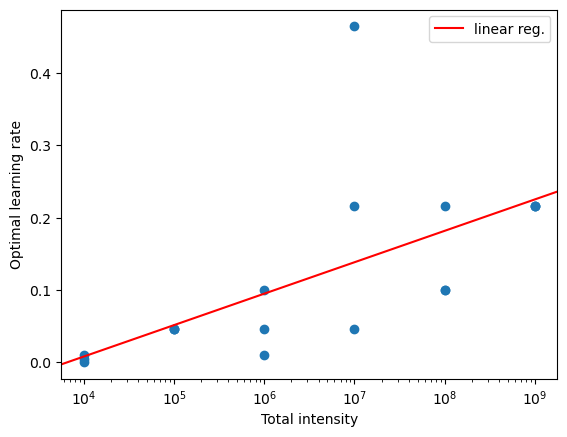

Model: 
	lr = 0.0188 * log(total_intensity) + -0.1655


In [8]:
from sklearn import linear_model

def plot_optimal_lr_vs_total_intensity(dataset: str = ""):
    x = list()
    y = list()
    if not dataset:
        for df in best_tables.values():
            x.append(df.index)
            y.append(df['best_lr'])
        x, y = np.concatenate(x), np.concatenate(y)
    else:
        x = np.array(best_tables[dataset].index)
        y = np.array(best_tables[dataset]['best_lr'])
    mask = (1e4 <= x) & (x <= 1e9)
    x = x[mask]
    y = y[mask]
    plt.scatter(x, y)
    plt.xlabel("Total intensity")
    plt.ylabel("Optimal learning rate")
    plt.xscale("log")


    # Fit linear model
    reg = linear_model.LinearRegression()
    X = np.log(x.reshape(len(x), 1))
    reg.fit(X, y)
    x_min, x_max = X.min(), X.max()
    pred_min, pred_max = reg.predict(np.array([x_min, x_max]).reshape(2, 1))
    plt.axline((np.exp(x_min), pred_min), (np.exp(x_max), pred_max), color='red', label='linear reg.')
    plt.legend()
    plt.show()
    plt.close()
    print(f"Model: \n\tlr = {round(reg.coef_.item(), 4)} * log(total_intensity) + {round(reg.intercept_.item(), 4)}")
# plot_optimal_lr_vs_total_intensity("composite")
# plot_optimal_lr_vs_total_intensity("lamino")
# plot_optimal_lr_vs_total_intensity("lung")
plot_optimal_lr_vs_total_intensity()